#Exploratory Data Analysis 
**Name:** Areeba Amjad

**Task 1: Importing the libraries**

In [2]:
import pandas as pd                #Reading the dataset
import numpy as np                 #Mathematical Operations 
import matplotlib.pyplot as plt    #Visualization
import seaborn as sns              #Better Graph Visualization

**Task 2: Loading the Retail Dataset**

In [3]:
ds=pd.read_excel("C:/Users/Laptop Zone/OneDrive/Desktop/online_retail_II.xlsx")  

**Task 3: Displaying Basic Information**

In [4]:
print("\n======Shape of Dataset:==========\n",ds.shape)   
print("\n======Columns of Dataset:========\n")
print(ds.columns)
print("\n======DataType of Dataset:=======\n")
print(ds.dtypes)



======Shape of Dataset:==========
 (525461, 8)

======Columns of Dataset:========

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

======DataType of Dataset:=======

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


**Task 4: Identification of Missing Values and Duplicating Rows**

In [5]:
print("Missing Values:\n")
print(ds.isnull().sum())        
print("\nDuplicated Rows:",ds.duplicated().sum())

Missing Values:

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Duplicated Rows: 6865


**Task 5: Revenue Calculation**

In [6]:
ds["Revenue"]=ds["Quantity"] * ds["Price"]    #Creating a new column of Revenue in Dataset
ds.head()                                     #Displaying few rows from Dataset

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


**Task 6: Top 10 best-selling products**

In [7]:
#Displaying Top 10 products grouped by Quantity
top_Quantity= ds.groupby("Description")["Quantity"].sum()
top_Quantity = top_Quantity.sort_values(ascending=False)
top_Quantity = top_Quantity.head(10)
print("\n========= Top 10 Products by Quantity========\n\n",top_Quantity)

#Displaying Top 10 products grouped by Revenue
top_Revenue= ds.groupby("Description")["Revenue"].sum()
top_Revenue = top_Revenue.sort_values(ascending=False)
top_Revenue = top_Revenue.head(10)
print("\n========= Top 10 Products by Revenue========\n\n",top_Revenue)



========= Top 10 Products by Quantity========

 Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64

========= Top 10 Products by Revenue========

 Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE           

**Task 7: Sales Performance by Country**

In [8]:
sales_performance=ds.groupby("Country").agg({           
    "Revenue": "sum",
    "Quantity": "sum",
    "Invoice": "nunique"})
sales_performance=sales_performance.sort_values(by="Revenue",ascending=False)    #Sorting Data in Descending order
sales_performance.columns=["Total Revenue","Total Quantity","Total Orders"]      #Renaming Columns for better understanding
sales_performance=sales_performance.head(10)                      
print(sales_performance)


                Total Revenue  Total Quantity  Total Orders
Country                                                    
United Kingdom    8194777.533         4429046         26633
EIRE               352242.730          188704           457
Netherlands        263863.410          181823           150
Germany            196290.351          107133           513
France             130769.900           74471           297
Sweden              51213.510           52238            83
Denmark             46972.950          227030            33
Switzerland         43343.410           22053            50
Spain               37084.900           18332            85
Australia           30051.800           20053            50


**Sales Performance Visualized by Bar Graph**

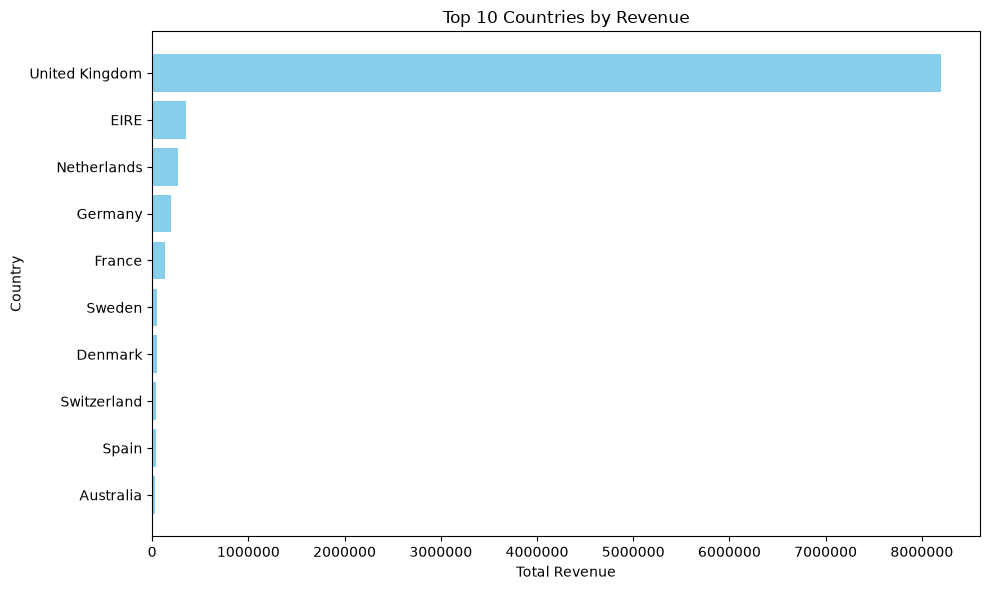

In [9]:
top10=sales_performance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10.index, top10["Total Revenue"], color="skyblue")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Task 8: Monthly Revenue Trend**

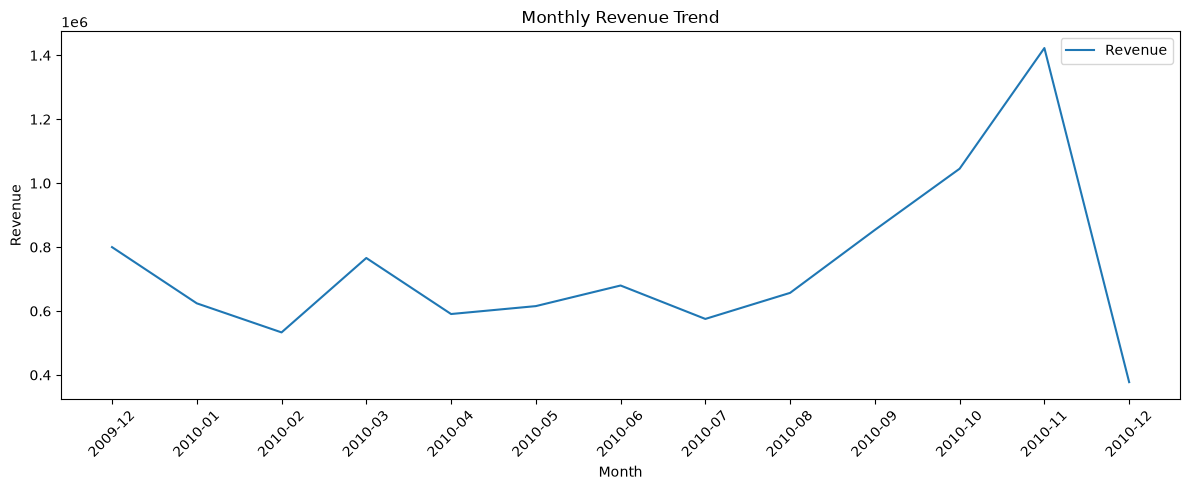

In [10]:
ds["InvoiceDate"]=pd.to_datetime(ds["InvoiceDate"])  # Converting InvoiceDate to proper date format in python
ds["Month"]=ds["InvoiceDate"].dt.to_period("M")                
monthly_revenue=ds.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(12,5)) 
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values,label='Revenue')
plt.legend()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue") 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()


**Task 9: Correlation Heatmap**

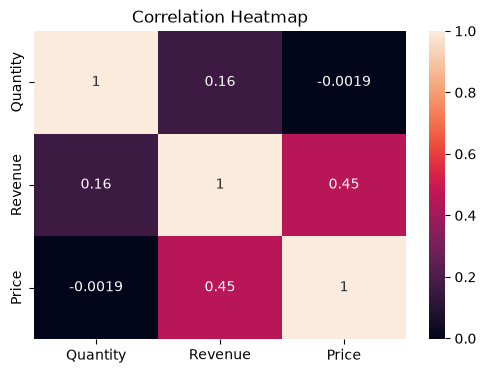

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(ds[['Quantity','Revenue','Price']].corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Task 10: Outlier Detection Using Boxplot**

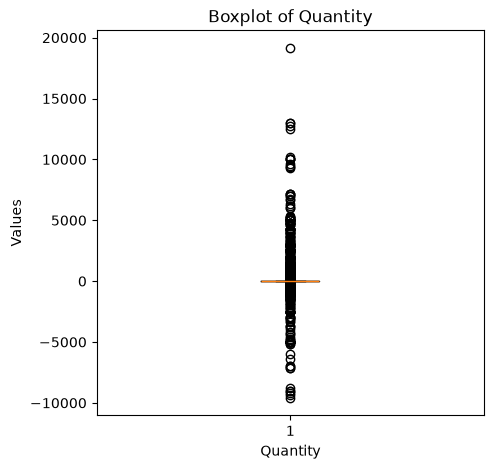

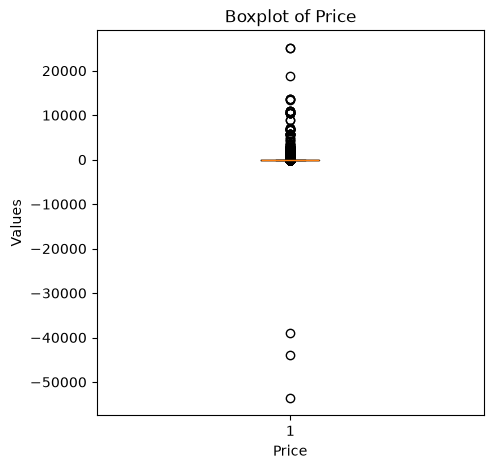

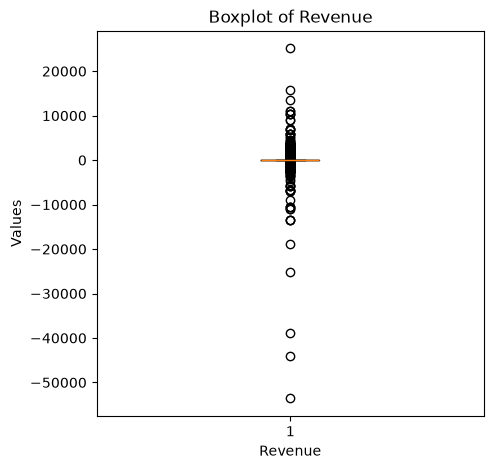

In [12]:
plt.figure(figsize=(5,5))
plt.boxplot(ds['Quantity'])               # Outlier detection for Quantity
plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Values")
plt.show()

plt.figure(figsize=(5,5))
plt.boxplot(ds['Price'])                 # Outlier detection for Price
plt.title("Boxplot of Price")
plt.xlabel("Price")
plt.ylabel("Values")
plt.show()

plt.figure(figsize=(5,5))
plt.boxplot(ds['Revenue'])              # Outlier detection for Revenue
plt.title("Boxplot of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Values")
plt.show()


**Business Insights**

1.	United Kingdom is the company’s primary market as highest revenue was generated there as compared to other countries.
2.	Monthly revenue fluctuated throughout the observed period which indicates that customer purchasing behaviors changes frequently.
3.	Few products contributes more to the revenue and the total sales which indicates these products are in high demand.
4.	Higher priced products contribute more to the revenue than the quantity sold.
5.	Quantity boxplot indicates bulk purchases and Revenue boxplot indicates high-value transactions.
